# Single spin Part 3: Single qubit gate optimisation using GRAPE

#### 1. Generate a PWC pulse shape

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cthree.quantity import Quantity
from cthree.signal.envelopes import GaussEnvelope
from cthree.signal.pwc_generator import PWCGenerator

First, let's generate a piecewise constant (PWC) pulse envelope for the Gaussian pulse

In [2]:
t_final = 20e-9
tlist = np.linspace(0, t_final, 101)
tone = GaussEnvelope(amplitude=Quantity(2 * np.pi / t_final / 3, -5 * np.pi / t_final, 5 * np.pi / t_final))
tone.t_final.set_value(t_final)
gen = PWCGenerator(envelopes=[tone], tlist=tlist)
gen.multiply_flat_top = True

In [3]:
params = gen.get_parameters()

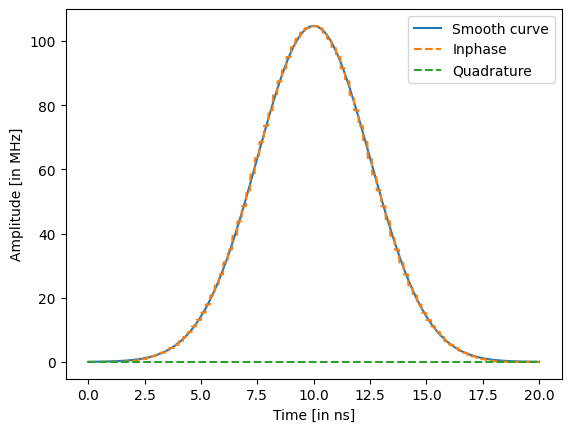

In [4]:
ts = np.linspace(0, t_final, 1001)

plt.plot(ts / 1e-9, tone.compute_output(ts) / 1e6, label="Smooth curve")
plt.plot(ts / 1e-9, np.real(gen.generate_signal(ts)) / 1e6, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()

#### 2. Define Hamiltonian in the rotating frame of drive

Next, we setup the qubit system we want to control. We define the Hamiltonian in the rotating frame of drive such that the pulse oscillates slowly to apply GRAPE gradients.

The Hamiltonain in the rotating frame of the drive is given by - 
$$ H(t) = \big(\omega_q - \omega_d\big) b^\dagger b -\frac{\alpha}{2} (b^\dagger)^2 b^2 + (\epsilon(t) b + \epsilon(t)^* b)$$

In [5]:
from cthree.quantity import Quantity
from cthree.model.closed_system import ClosedSystem
from cthree.model.rotating_frame_drive import RotatingFrameDrive
from cthree.model.transmon import Transmon


FREQ = 7.86e9 * 2 * np.pi
DIMS = 3
ANHARM = -50e6 * 2 * np.pi
offset = 5e6 * 2 * np.pi

drive_freq = FREQ + offset
qubit_freq = FREQ - drive_freq

Drive = RotatingFrameDrive(gen)
transmon = Transmon(
    frequency=Quantity(
        qubit_freq,
        1.2 * qubit_freq,
        0.8 * qubit_freq,
        unit="Hz",
        name="Frequency",
    ),
    anharmonicity=Quantity(ANHARM, 1.2 * ANHARM, 0.8 * ANHARM, unit="Hz", name="Anharmonicity"),
    drives=[Drive],
    dimension=DIMS,
)

model = ClosedSystem(transmon)

In [6]:
from cthree.measurement.state_transfer_fidelity import StateTransferFidelityGRAPE
from cthree.propagation.scipy_expm_grape import ScipyExpmGRAPE


prop = ScipyExpmGRAPE(model, res=1e9)

init = np.array([[1.0], [0.0], [0]])  # |0>
target = np.array([[0.0], [1.0], [0]])  # |1>

prop.set_initial_state(init)
prop.set_target_state(target)

prop.use_schirmer_derivative(True)

zeroone = StateTransferFidelityGRAPE(
    propagation=prop,
    initial_state=init,
    target_state=target,
    times=tlist,
)

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

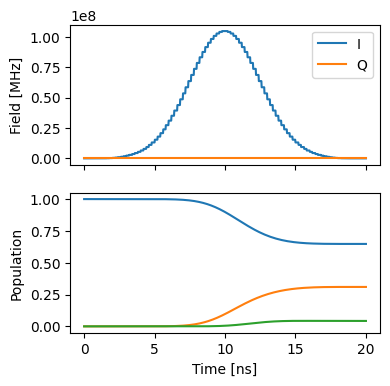

In [7]:
def plotStates():
    """Plot the states."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, np.real(sig), label="I")
    ax[0].plot(ts / 1e-9, np.imag(sig), label="Q")
    ax[0].legend(loc=1)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, np.abs(states)[:, :, 0] ** 2)
    ax[1].set_ylabel("Population")
    ax[-1].set_xlabel("Time [ns]")
    return fig, ax


plotStates()

As expected, we get a partial transfer and a low fidelity.

In [8]:
zeroone.measure()

Array(0.30972642, dtype=float64)

We define an optimizer and link our fidelity measure as a goal function and the parameters of the cosine tone and optimise just amplitude and frequency, as in the state transfer example.

In [9]:
from cthree.optimisation_map import OptimisationMap
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient

optmap = OptimisationMap()
optmap.add(gen, params)
opt = ScipyOptimiserGradient(zeroone, optimisables=optmap)

In [10]:
opt.optimise()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          200     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.90274D-01    |proj g|=  4.17998D-02

At iterate    1    f=  6.13236D-01    |proj g|=  4.44069D-02
  ys=-2.843E-03  -gs= 7.542E-02 BFGS update SKIPPED

At iterate    2    f=  2.18669D-01    |proj g|=  3.64686D-02

At iterate    3    f=  4.43900D-02    |proj g|=  1.59609D-02

At iterate    4    f=  8.98158D-03    |proj g|=  5.65267D-03

At iterate    5    f=  2.99967D-03    |proj g|=  2.39167D-03

At iterate    6    f=  2.02061D-03    |proj g|=  1.79879D-03

At iterate    7    f=  4.56475D-04    |proj g|=  1.13877D-03

At iterate    8    f=  3.85338D-05    |proj g|=  6.15638D-04

At iterate    9    f=  1.49313D-06    |proj g|=  1.45998D-04

At iterate   10    f=  2.43395D-08    |proj g|=  9.90021D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations


{'status': 1, 'value': 2.4339517179505776e-08, 'iterations': 13, 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

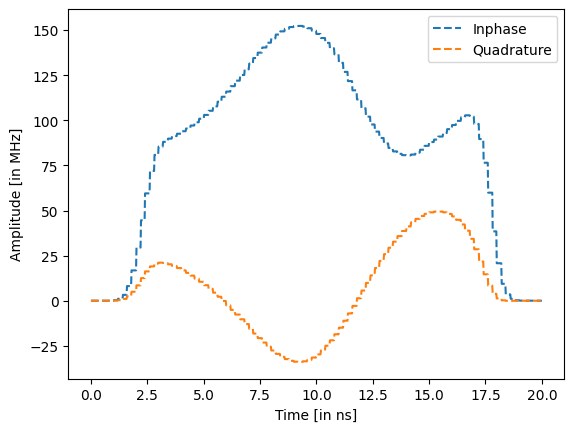

In [11]:
ts = np.linspace(0, t_final, 1001)

plt.plot(ts / 1e-9, np.real(gen.generate_signal(ts)) / 1e6, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

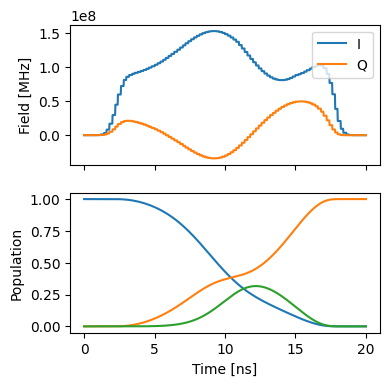

In [12]:
plotStates()